# Mérési notebook
---
# **3. mérési fázis**. A	Modellek tesztelése teljes tanítással.

#### **Cél**: Modellek tesztelése saját adathalmazon, majd saját modell ötletek tesztelése
#### **Diplomamunka címe**: Fotográfiai témafelismerés neurális hálózatokkal nagy adathalmazon.
#### **Készítette**: Sándor Balázs - AZA6NL

## 2. modell **DenseNet121** modell teljes tanítással történő tesztelése

#### A DenseNet121 modell tesztelése 1k, 5k, 10k, 25k tanítás után a saját SBphotothemes180k adathalmaz Test részhalmazán. (teszt elemszám: 18k).

---

✅ 3. FÁZIS: DenseNet121 – Few-shot fine-tune

🧪 DenseNet121 @ Few-shot Fine-tune (1k / 5k / 10k / 25k)

🎯 Cél:
Megvizsgálni, hogyan változik a DenseNet121 teljesítménye különböző mennyiségű adat esetén.

✅ 1. Telepítés, import, GPU ellenőrzés

In [ ]:
!pip install -q --upgrade pip
!pip install -q timm torchvision tqdm scikit-learn matplotlib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
import numpy as np
import random, os, time
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    top_k_accuracy_score, confusion_matrix
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("💻 Eszköz:", device)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 176.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 195.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 148.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 158.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 146.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 187.0 MB/s eta 0:00:00
💻 Eszköz: cuda


✅ 2. Drive csatolása és adatbázis kicsomagolása

In [ ]:
from google.colab import drive
import zipfile

drive.mount('/content/drive')

diploma_path = "/content/drive/MyDrive/diplomamunka"
zip_path = os.path.join(diploma_path, "imagenet_splitted_db.zip")
extract_path = "/content/imagenet_splitted_db"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

print("✅ Adatok elérhetők:", extract_path)


Mounted at /content/drive
✅ Adatok elérhetők: /content/imagenet_splitted_db


Mappa pontosítás

In [ ]:
extract_path = "/content/imagenet_splitted_db/imagenet_splitted_db"

✅ 3. Adatok előkészítése és stratifikált részhalmazok létrehozása

In [ ]:
from collections import defaultdict

# Képek transzformációja
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Teljes train / val / test betöltése
train_dataset_full = datasets.ImageFolder(os.path.join(extract_path, "train"), transform=transform)
val_dataset         = datasets.ImageFolder(os.path.join(extract_path, "val"), transform=transform)
test_dataset        = datasets.ImageFolder(os.path.join(extract_path, "test"), transform=transform)

# Stratifikált mintavétel
def stratified_subset(dataset, total_images):
    class_indices = defaultdict(list)
    for idx, (_, label) in enumerate(dataset.samples):
        class_indices[label].append(idx)

    per_class = total_images // len(class_indices)
    selected_indices = []

    for cls, indices in class_indices.items():
        chosen = random.sample(indices, min(per_class, len(indices)))
        selected_indices.extend(chosen)

    print(f"📦 {total_images} képes részhalmaz kész.")
    return Subset(dataset, selected_indices)

# 4 részhalmaz (1k, 5k, 10k, 25k)
subset_sizes = [1000, 5000, 10000, 25000]
subsets = {f"{size}": stratified_subset(train_dataset_full, size) for size in subset_sizes}

# Teszt és validációs betöltők
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

class_names = train_dataset_full.classes
num_classes = len(class_names)


📦 1000 képes részhalmaz kész.
📦 5000 képes részhalmaz kész.
📦 10000 képes részhalmaz kész.
📦 25000 képes részhalmaz kész.


✅ 4. DenseNet121 modell létrehozása (új output layerrel)

In [ ]:
def get_densenet121_model():
    model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
    model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    return model.to(device)


✅ 5. Általános tanító függvény

In [ ]:
def train_on_subset(train_dataset, subset_name, num_epochs=10):
    print(f"\n🚀 Tanítás: {subset_name} képes részhalmaz")

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
    model = get_densenet121_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    train_loss_hist, val_loss_hist = [], []
    train_acc_hist, val_acc_hist = [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - train"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total
        train_loss_hist.append(train_loss)
        train_acc_hist.append(train_acc)

        # Validáció
        model.eval()
        val_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss /= total
        val_acc = correct / total
        val_loss_hist.append(val_loss)
        val_acc_hist.append(val_acc)

        print(f"📊 Epoch {epoch+1}: Train loss={train_loss:.4f}, acc={train_acc:.4f} | Val loss={val_loss:.4f}, acc={val_acc:.4f}")

    return model, train_loss_hist, val_loss_hist, train_acc_hist, val_acc_hist


🔷 BLOKK 1 – 1k képes tanítóhalmaz DenseNet121


🚀 Tanítás: 1k képes részhalmaz


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 163MB/s] 
Epoch 1/10 - train: 100%|██████████| 15/15 [00:03<00:00,  4.48it/s]


📊 Epoch 1: Train loss=4.7857, acc=0.0143 | Val loss=4.6317, acc=0.0246


Epoch 2/10 - train: 100%|██████████| 15/15 [00:02<00:00,  7.29it/s]


📊 Epoch 2: Train loss=3.9205, acc=0.3662 | Val loss=4.3919, acc=0.0965


...

📊 Epoch 8: Train loss=1.3594, acc=0.9978 | Val loss=3.6529, acc=0.2420


Epoch 9/10 - train: 100%|██████████| 15/15 [00:02<00:00,  7.36it/s]


📊 Epoch 9: Train loss=1.1032, acc=0.9978 | Val loss=3.5557, acc=0.2530


Epoch 10/10 - train: 100%|██████████| 15/15 [00:02<00:00,  7.29it/s]


📊 Epoch 10: Train loss=0.8931, acc=0.9989 | Val loss=3.5198, acc=0.2569


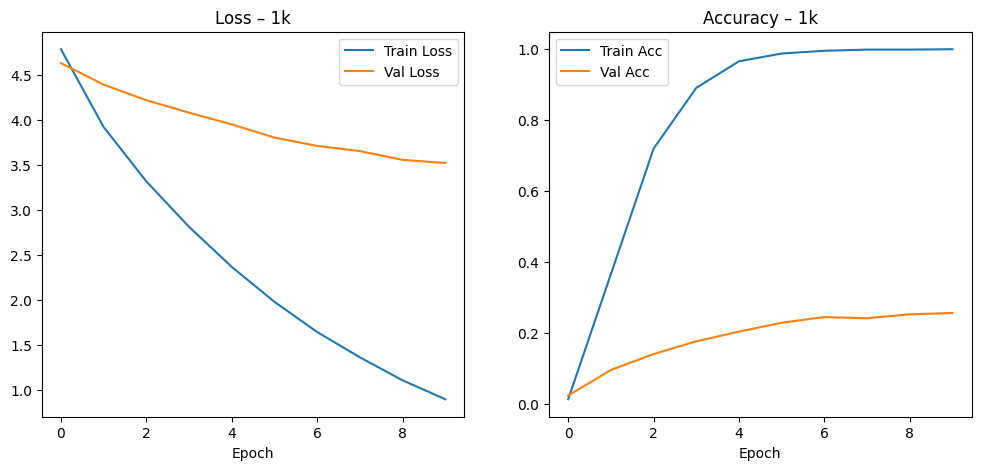


🔍 Metrikák – DenseNet121 trained on 1k:
✅ Top-1 Accuracy:  0.2648
✅ Top-5 Accuracy:  0.5513
🎯 Precision:       0.2636
🎯 Recall:          0.2863
🎯 F1-score:        0.2542
⏱️ Inference time:  25.09 sec


In [ ]:
# 🔧 Tanítás 1k halmazon
model_1k, train_loss_1k, val_loss_1k, train_acc_1k, val_acc_1k = train_on_subset(subsets["1000"], "1k", num_epochs=10)

# 📉 Tanulási görbe – 1k
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss_1k, label="Train Loss")
plt.plot(val_loss_1k, label="Val Loss")
plt.title("Loss – 1k")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_1k, label="Train Acc")
plt.plot(val_acc_1k, label="Val Acc")
plt.title("Accuracy – 1k")
plt.xlabel("Epoch")
plt.legend()
plt.show()

# 🧪 Tesztelés 1k modellen
model_1k.eval()
all_preds, all_probs, all_labels = [], [], []
start = time.perf_counter()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_1k(inputs)
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

inference_time = time.perf_counter() - start
y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_probs = np.array(all_probs)

print("\n🔍 Metrikák – DenseNet121 trained on 1k:")
print(f"✅ Top-1 Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"✅ Top-5 Accuracy:  {top_k_accuracy_score(y_true, y_probs, k=5):.4f}")
print(f"🎯 Precision:       {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 Recall:          {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 F1-score:        {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"⏱️ Inference time:  {inference_time:.2f} sec")


🔷 BLOKK 2 – 5k képes tanítóhalmaz DenseNet121


🚀 Tanítás: 5k képes részhalmaz


Epoch 1/10 - train: 100%|██████████| 77/77 [00:09<00:00,  8.05it/s]


📊 Epoch 1: Train loss=4.2642, acc=0.1293 | Val loss=3.5880, acc=0.2444


Epoch 2/10 - train: 100%|██████████| 77/77 [00:09<00:00,  8.19it/s]


📊 Epoch 2: Train loss=3.0089, acc=0.4219 | Val loss=2.9462, acc=0.3370


...

📊 Epoch 8: Train loss=0.3972, acc=0.9825 | Val loss=2.2675, acc=0.4203


Epoch 9/10 - train: 100%|██████████| 77/77 [00:09<00:00,  8.08it/s]


📊 Epoch 9: Train loss=0.2468, acc=0.9929 | Val loss=2.2026, acc=0.4391


Epoch 10/10 - train: 100%|██████████| 77/77 [00:09<00:00,  8.04it/s]


📊 Epoch 10: Train loss=0.1610, acc=0.9969 | Val loss=2.2519, acc=0.4223


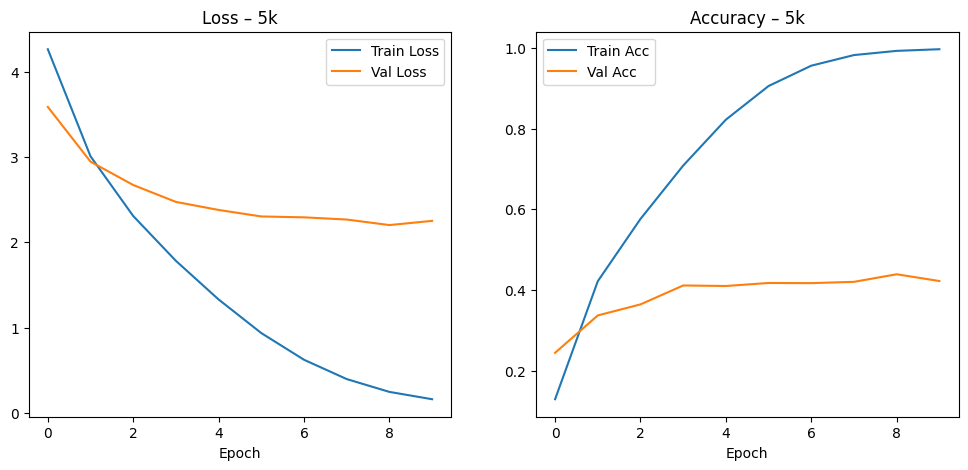


🔍 Metrikák – DenseNet121 trained on 5k:
✅ Top-1 Accuracy:  0.4309
✅ Top-5 Accuracy:  0.7514
🎯 Precision:       0.3957
🎯 Recall:          0.4491
🎯 F1-score:        0.4049
⏱️ Inference time:  24.87 sec


In [ ]:
# 🔧 Tanítás 5k halmazon
model_5k, train_loss_5k, val_loss_5k, train_acc_5k, val_acc_5k = train_on_subset(subsets["5000"], "5k", num_epochs=10)

# 📉 Tanulási görbe – 5k
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss_5k, label="Train Loss")
plt.plot(val_loss_5k, label="Val Loss")
plt.title("Loss – 5k")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_5k, label="Train Acc")
plt.plot(val_acc_5k, label="Val Acc")
plt.title("Accuracy – 5k")
plt.xlabel("Epoch")
plt.legend()
plt.show()

# 🧪 Tesztelés 5k modellen
model_5k.eval()
all_preds, all_probs, all_labels = [], [], []
start = time.perf_counter()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_5k(inputs)
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

inference_time = time.perf_counter() - start
y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_probs = np.array(all_probs)

print("\n🔍 Metrikák – DenseNet121 trained on 5k:")
print(f"✅ Top-1 Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"✅ Top-5 Accuracy:  {top_k_accuracy_score(y_true, y_probs, k=5):.4f}")
print(f"🎯 Precision:       {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 Recall:          {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 F1-score:        {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"⏱️ Inference time:  {inference_time:.2f} sec")


🔷 BLOKK 3 – 10k képes tanítóhalmaz DenseNet121


🚀 Tanítás: 10k képes részhalmaz


Epoch 1/10 - train: 100%|██████████| 155/155 [00:18<00:00,  8.16it/s]


📊 Epoch 1: Train loss=3.7089, acc=0.2201 | Val loss=2.8225, acc=0.3651


Epoch 2/10 - train: 100%|██████████| 155/155 [00:18<00:00,  8.16it/s]


📊 Epoch 2: Train loss=2.4529, acc=0.4618 | Val loss=2.4133, acc=0.4091


...

📊 Epoch 8: Train loss=0.1926, acc=0.9873 | Val loss=2.0269, acc=0.4720


Epoch 9/10 - train: 100%|██████████| 155/155 [00:19<00:00,  8.01it/s]


📊 Epoch 9: Train loss=0.1117, acc=0.9942 | Val loss=2.0559, acc=0.4789


Epoch 10/10 - train: 100%|██████████| 155/155 [00:19<00:00,  8.14it/s]


📊 Epoch 10: Train loss=0.0667, acc=0.9971 | Val loss=2.1183, acc=0.4737


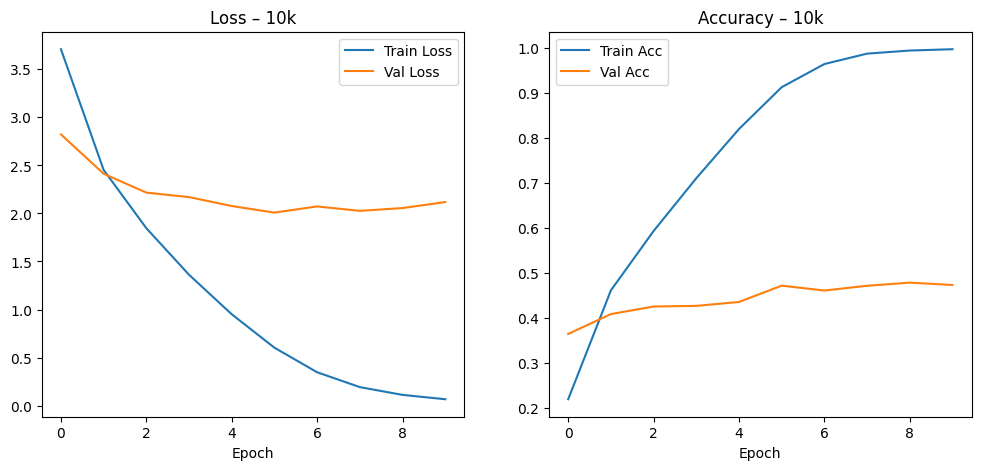


🔍 Metrikák – DenseNet121 trained on 10k:
✅ Top-1 Accuracy:  0.4793
✅ Top-5 Accuracy:  0.7849
🎯 Precision:       0.4390
🎯 Recall:          0.5065
🎯 F1-score:        0.4542
⏱️ Inference time:  25.02 sec


In [ ]:
model_10k, train_loss_10k, val_loss_10k, train_acc_10k, val_acc_10k = train_on_subset(subsets["10000"], "10k", num_epochs=10)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss_10k, label="Train Loss")
plt.plot(val_loss_10k, label="Val Loss")
plt.title("Loss – 10k")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_10k, label="Train Acc")
plt.plot(val_acc_10k, label="Val Acc")
plt.title("Accuracy – 10k")
plt.xlabel("Epoch")
plt.legend()
plt.show()

model_10k.eval()
all_preds, all_probs, all_labels = [], [], []
start = time.perf_counter()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_10k(inputs)
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

inference_time = time.perf_counter() - start
y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_probs = np.array(all_probs)

print("\n🔍 Metrikák – DenseNet121 trained on 10k:")
print(f"✅ Top-1 Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"✅ Top-5 Accuracy:  {top_k_accuracy_score(y_true, y_probs, k=5):.4f}")
print(f"🎯 Precision:       {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 Recall:          {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 F1-score:        {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"⏱️ Inference time:  {inference_time:.2f} sec")


🔷 BLOKK 4 – 25k képes tanítóhalmaz DenseNet121


🚀 Tanítás: 25k képes részhalmaz


Epoch 1/10 - train: 100%|██████████| 391/391 [00:47<00:00,  8.23it/s]


📊 Epoch 1: Train loss=3.0551, acc=0.3175 | Val loss=2.2636, acc=0.4364


Epoch 2/10 - train: 100%|██████████| 391/391 [00:47<00:00,  8.26it/s]


📊 Epoch 2: Train loss=1.9269, acc=0.5255 | Val loss=1.9442, acc=0.4782


...

📊 Epoch 8: Train loss=0.1689, acc=0.9703 | Val loss=2.0438, acc=0.5145


Epoch 9/10 - train: 100%|██████████| 391/391 [00:47<00:00,  8.22it/s]


📊 Epoch 9: Train loss=0.1524, acc=0.9730 | Val loss=2.1919, acc=0.5052


Epoch 10/10 - train: 100%|██████████| 391/391 [00:47<00:00,  8.20it/s]


📊 Epoch 10: Train loss=0.1022, acc=0.9829 | Val loss=2.0833, acc=0.5307


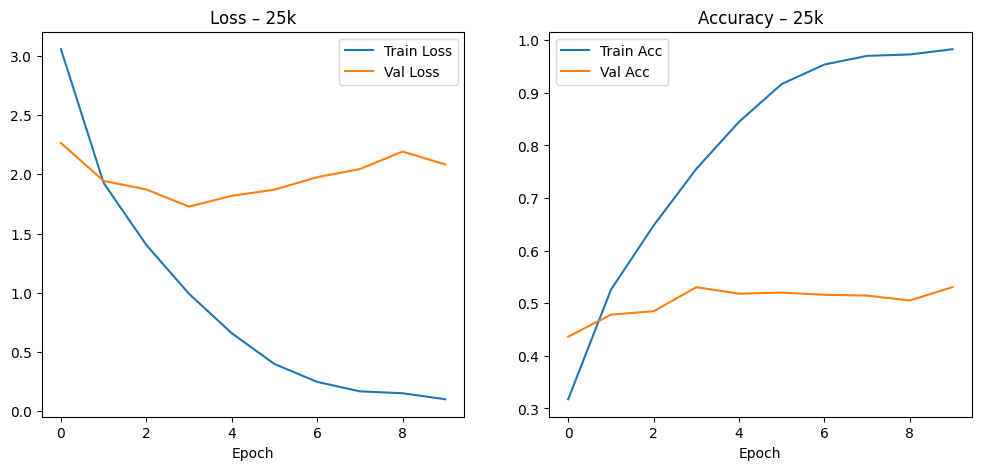


🔍 Metrikák – DenseNet121 trained on 25k:
✅ Top-1 Accuracy:  0.5366
✅ Top-5 Accuracy:  0.8207
🎯 Precision:       0.5003
🎯 Recall:          0.5739
🎯 F1-score:        0.5171
⏱️ Inference time:  24.71 sec


In [ ]:
model_25k, train_loss_25k, val_loss_25k, train_acc_25k, val_acc_25k = train_on_subset(subsets["25000"], "25k", num_epochs=10)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss_25k, label="Train Loss")
plt.plot(val_loss_25k, label="Val Loss")
plt.title("Loss – 25k")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_25k, label="Train Acc")
plt.plot(val_acc_25k, label="Val Acc")
plt.title("Accuracy – 25k")
plt.xlabel("Epoch")
plt.legend()
plt.show()

model_25k.eval()
all_preds, all_probs, all_labels = [], [], []
start = time.perf_counter()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_25k(inputs)
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

inference_time = time.perf_counter() - start
y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_probs = np.array(all_probs)

print("\n🔍 Metrikák – DenseNet121 trained on 25k:")
print(f"✅ Top-1 Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"✅ Top-5 Accuracy:  {top_k_accuracy_score(y_true, y_probs, k=5):.4f}")
print(f"🎯 Precision:       {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 Recall:          {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 F1-score:        {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"⏱️ Inference time:  {inference_time:.2f} sec")


✅ 🔢 Összevont tanulási görbék (Accuracy + Loss)

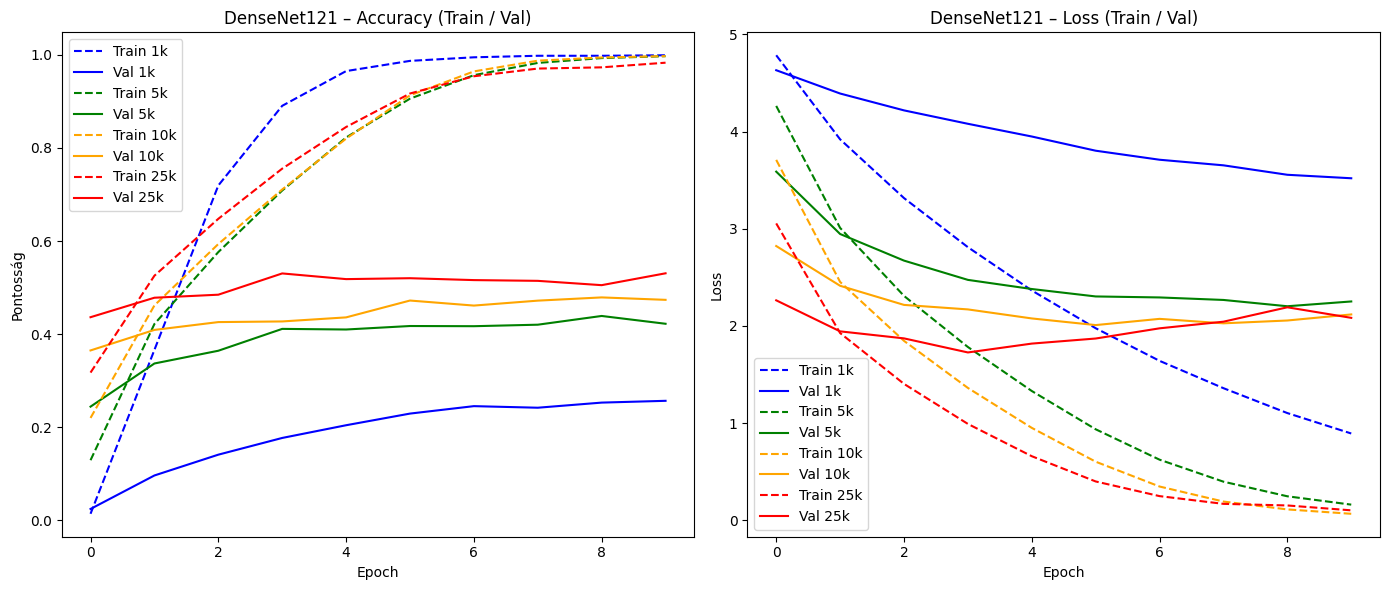

In [ ]:
plt.figure(figsize=(14, 6))

# --- Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(train_acc_1k, label="Train 1k", linestyle='--', color='blue')
plt.plot(val_acc_1k,   label="Val 1k",   color='blue')
plt.plot(train_acc_5k, label="Train 5k", linestyle='--', color='green')
plt.plot(val_acc_5k,   label="Val 5k",   color='green')
plt.plot(train_acc_10k, label="Train 10k", linestyle='--', color='orange')
plt.plot(val_acc_10k,   label="Val 10k",   color='orange')
plt.plot(train_acc_25k, label="Train 25k", linestyle='--', color='red')
plt.plot(val_acc_25k,   label="Val 25k",   color='red')
plt.title("DenseNet121 – Accuracy (Train / Val)")
plt.xlabel("Epoch")
plt.ylabel("Pontosság")
plt.legend()

# --- Loss ---
plt.subplot(1, 2, 2)
plt.plot(train_loss_1k, label="Train 1k", linestyle='--', color='blue')
plt.plot(val_loss_1k,   label="Val 1k",   color='blue')
plt.plot(train_loss_5k, label="Train 5k", linestyle='--', color='green')
plt.plot(val_loss_5k,   label="Val 5k",   color='green')
plt.plot(train_loss_10k, label="Train 10k", linestyle='--', color='orange')
plt.plot(val_loss_10k,   label="Val 10k",   color='orange')
plt.plot(train_loss_25k, label="Train 25k", linestyle='--', color='red')
plt.plot(val_loss_25k,   label="Val 25k",   color='red')
plt.title("DenseNet121 – Loss (Train / Val)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


✅ 🟦 Mini Confusion Matrix montázs (1k / 5k / 10k / 25k)

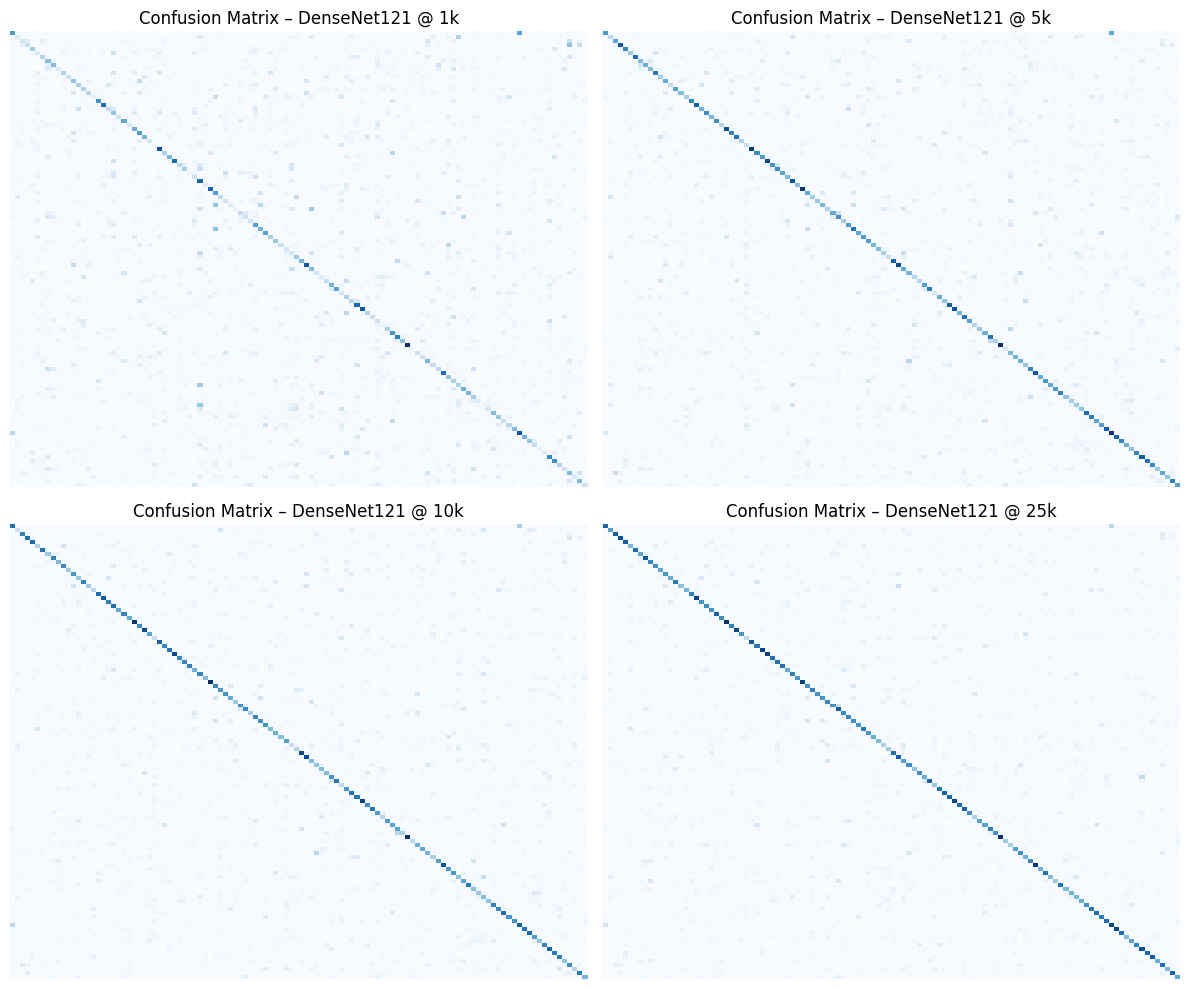

In [ ]:
import seaborn as sns

def plot_mini_confmat(model, title):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            p = torch.argmax(out, 1)
            preds.extend(p.cpu().numpy())
            labels.extend(y.cpu().numpy())

    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)

    sns.heatmap(cm_norm, cbar=False, xticklabels=False, yticklabels=False, cmap="Blues")

plt.figure(figsize=(12, 10))
for i, (model, title) in enumerate(zip(
    [model_1k, model_5k, model_10k, model_25k],
    ["1k", "5k", "10k", "25k"]
)):
    plt.subplot(2, 2, i+1)
    plot_mini_confmat(model, title)
    plt.title(f"Confusion Matrix – DenseNet121 @ {title}")

plt.tight_layout()
plt.show()
